# UK Climate Change Analysis: Evidence from 37 Weather Stations

**Deren Tuzun**

---

This project investigates whether the UK climate is changing, and in what ways, using historical weather data from 37 Met Office weather stations. The analysis combines exploratory visualisation, linear regression with seasonal decomposition, bootstrap inference, and chi-squared hypothesis testing.

**Data source:** [UK Met Office Historic Station Data](https://www.metoffice.gov.uk/research/climate/maps-and-data/historic-station-data)


## Introduction

This report looks at long-term weather changes across different parts of the United Kingdom. The analysis is based on monthly data from 37 weather stations provided by the UK Met Office, covering variables such as maximum temperature (TMax), rainfall, and the number of frost days.

> **Note on data:** The CSV files used in this analysis are not included in this repository. You can download the original data directly from the [Met Office Historic Station Data](https://www.metoffice.gov.uk/research/climate/maps-and-data/historic-station-data) page. Each station has its own file; download and rename them to match the filenames referenced in the code (e.g. `durhamdata.csv`, `oxforddata.csv`).

The project is structured in four parts:
- **Part 1** — Exploratory visualisation of climate trends across selected stations
- **Part 2** — Regression modelling and bootstrap confidence intervals for temperature trends
- **Part 3** — Chi-squared independence testing for changes in frost day patterns
- **Part 4** — Overall conclusions and interpretation of statistical evidence


## Setup
In this section I import the Python libraries used throughout the analysis.

In [33]:
# Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency
from sklearn.utils import resample


# Choosing a simple matplotlib style and a fixed random seed
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)



## Part 1 — Exploratory Analysis: Evidence for Changing Climate


## Step 1 – Data Preparation

Weather records from four stations (Durham, Oxford, Camborne, and Lerwick) were loaded and combined into a single dataframe. A `Location` label was added to each dataset so that the stations could be distinguished during analysis and plotting.

The datasets were merged using a simple Python list-based approach, keeping the preparation step straightforward and consistent with the exploratory nature of Part 1. No further transformations were applied at this stage; annual summaries and smoothing were calculated later during the visualisation steps.

The combined dataframe was briefly checked to confirm that the files were read correctly and the station labels were assigned as expected.



In [34]:
# Load datasets
durham   = pd.read_csv("durhamdata.csv");   durham["Location"] = "Durham"
oxford   = pd.read_csv("oxforddata.csv");   oxford["Location"] = "Oxford"
camborne = pd.read_csv("cambornedata.csv"); camborne["Location"] = "Camborne"
lerwick  = pd.read_csv("lerwickdata.csv");  lerwick["Location"] = "Lerwick"

# The station datasets are converted into record lists and combined into a single DataFrame.
weather = pd.DataFrame(
    [*durham.to_dict("records"),
     *oxford.to_dict("records"),
     *camborne.to_dict("records"),
     *lerwick.to_dict("records")]
)

weather.head()


,Year,Month,TMax,TMin,Frost,Rainfall,Sunshine,Status,Location
0,1880,1,4.2,-1.4,22.0,13.5,NaN,Confirmed,Durham
1,1880,2,8.7,0.6,12.0,44.3,NaN,Confirmed,Durham
2,1880,3,9.2,1.0,12.0,32.5,NaN,Confirmed,Durham
3,1880,4,11.6,2.7,2.0,51.5,NaN,Confirmed,Durham
4,1880,5,14.1,3.7,4.0,38.1,NaN,Confirmed,Durham


## Step 2 – Maximum Temperature (TMax) Trends

This section examines long-term maximum temperature (TMax) changes for four stations **(Durham, Oxford, Camborne, and Lerwick)**. Monthly measurements were converted into **annual averages** to provide a clearer view of overall temperature patterns over time.

Annual average TMax values were **plotted for each station**, followed by an **11-year rolling mean** to highlight long-term patterns. This smoothing reduces the influence of seasonal fluctuations, making long-term temperature trends easier to interpret.


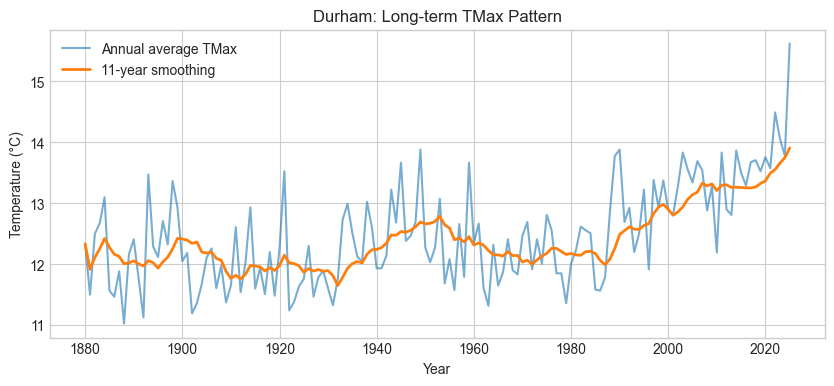

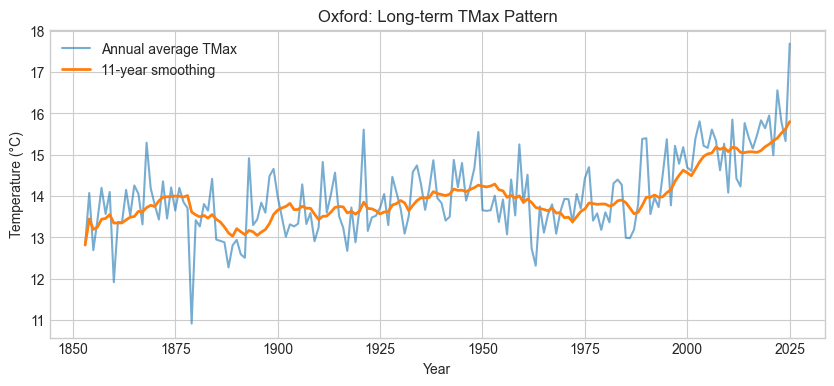

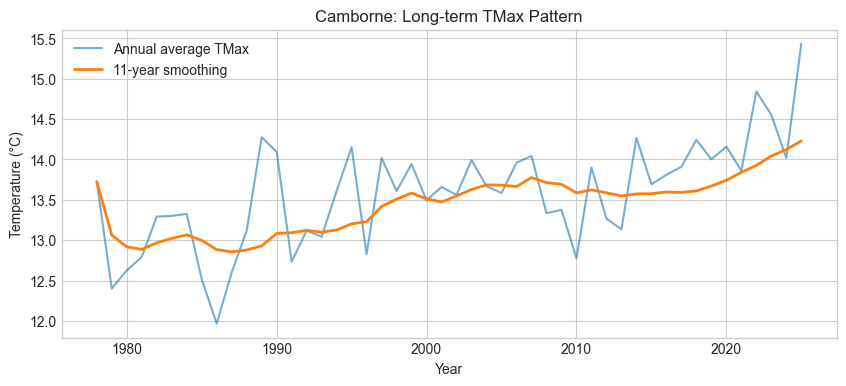

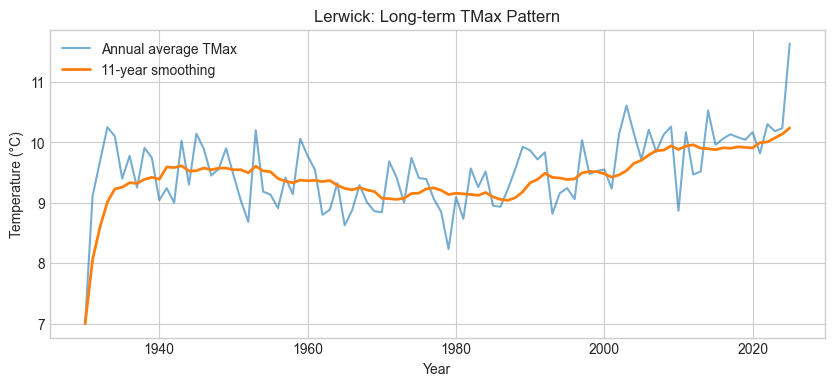

In [35]:
# Task 1: Long-term TMax trends across four stations

selected_stations = ["Durham", "Oxford", "Camborne", "Lerwick"]

for station in selected_stations:
    
# filter the dataset for the current station
    station_data = weather[weather["Location"] == station]
    
# compute yearly average TMax
    yearly_avg = (
        station_data.groupby("Year")["TMax"]
                    .mean()
                    .reset_index()
    )
    
    plt.figure(figsize=(10, 4))
    
# raw yearly average series
    plt.plot(
        yearly_avg["Year"],
        yearly_avg["TMax"],
        label="Annual average TMax",
        alpha=0.6
    )
    
# smoother long-term pattern (11-year rolling window)
    smooth_trend = yearly_avg["TMax"].rolling(11, min_periods=1).mean()
    plt.plot(
        yearly_avg["Year"],
        smooth_trend,
        linewidth=2,
        label="11-year smoothing"
    )
    
    plt.title(f"{station}: Long-term TMax Pattern")
    plt.xlabel("Year")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.show()




### Durham – Maximum Temperature Trend

Maximum temperatures in Durham fluctuate over a long period without showing a clear change. However, an upward trend begins to appear after the 1970s and becomes more pronounced from the 2000s onwards. Despite short-term variations, the overall pattern indicates a long-term increase in maximum temperatures in Durham.

### Oxford – Maximum Temperature Trend

In Oxford, maximum temperatures vary considerably in the early part of the record but do not display a clear trend. From the 1970s onwards, an upward trend becomes evident, and recent years show higher temperature levels compared with earlier decades. Overall, the graph supports the presence of a long-term increasing trend in maximum temperatures in Oxford.

### Camborne – Maximum Temperature Trend

In Camborne, maximum temperatures remain relatively stable for much of the record. However, after the 1990s, a noticeable upward trend begins to emerge. Although year-to-year fluctuations continue, recent values are generally higher than those observed in earlier periods, indicating a long-term rise in maximum temperatures.

### Lerwick – Maximum Temperature Trend

Maximum temperatures in Lerwick stay fairly stable for a long period, with no strong changes early on. However, a slight upward trend becomes visible from the late 1990s. Although the trend is not very strong, the overall pattern suggests a gradual long-term increase in maximum temperatures over time.

### Overall TMax Comparison

Across all four stations, maximum temperatures show a broadly consistent long-term pattern, with clear upward trends emerging over time. Although the timing and steepness of these increases vary slightly between stations, each location displays a noticeable rise in maximum temperatures in the later part of the record. Despite short-term fluctuations, the overall evidence indicates that maximum temperatures have increased at all four stations throughout the observation period.


## Step 3 - Rainfall Trends

This section examines long-term changes in **annual rainfall totals** at four stations **(Durham, Oxford, Camborne, and Lerwick)**. Because rainfall varies substantially from month to month, annual totals are used to provide a clearer illustration of broader trends.

Annual rainfall totals are **plotted for each station**, and an **eight-year smoothing** is applied to reduce short-term fluctuations. This approach helps minimise the influence of high monthly variability, making long-term rainfall patterns easier to interpret.



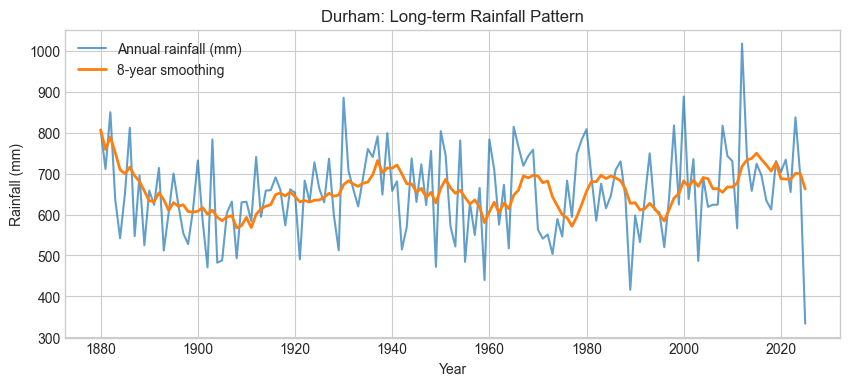

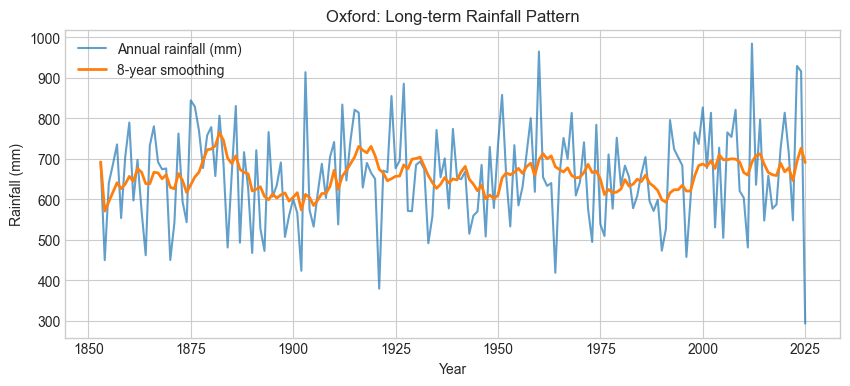

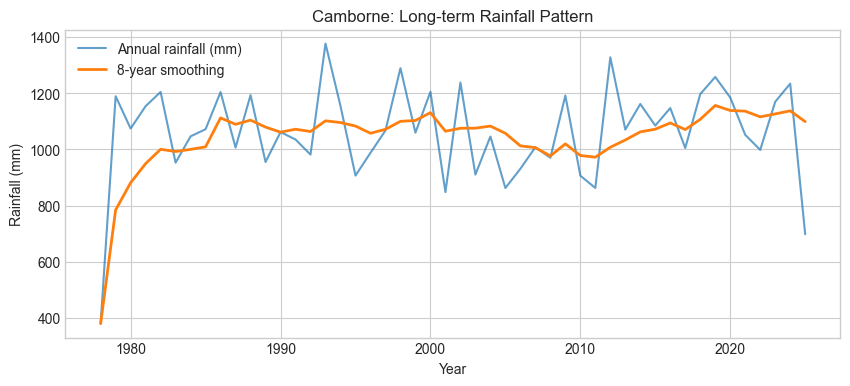

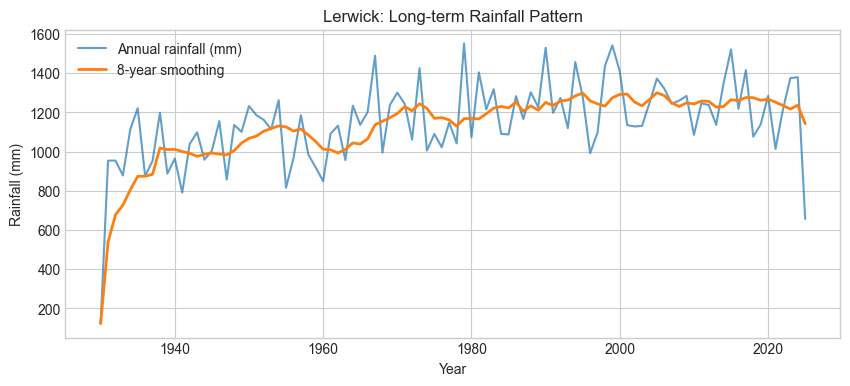

In [36]:
# Task 1: Rainfall trends for four stations

selected_stations = ["Durham", "Oxford", "Camborne", "Lerwick"]

for station in selected_stations:
    
# filter dataset for the selected location
    station_data = weather[weather["Location"] == station]
    
# compute yearly total rainfall
    yearly_rain = (
        station_data.groupby("Year")["Rainfall"]
                    .sum()
                    .reset_index()
    )
    
    plt.figure(figsize=(10, 4))
    
# annual rainfall totals
    plt.plot(
        yearly_rain["Year"],
        yearly_rain["Rainfall"],
        alpha=0.7,
        label="Annual rainfall (mm)"
    )
    
# smoothing for long-term signal
    smooth_rain = yearly_rain["Rainfall"].rolling(8, min_periods=1).mean()
    plt.plot(
        yearly_rain["Year"],
        smooth_rain,
        linewidth=2,
        label="8-year smoothing"
    )
    
    plt.title(f"{station}: Long-term Rainfall Pattern")
    plt.xlabel("Year")
    plt.ylabel("Rainfall (mm)")
    plt.legend()
    plt.show()


### Durham – Rainfall Trend

Annual rainfall in Durham varies considerably over time without showing a clear long-term trend. Although some periods display increases or decreases, these shifts do not form a consistent pattern. Overall, the graph indicates a highly variable rainfall structure rather than a stable upward or downward trend.

### Oxford – Rainfall Trend

Annual rainfall in Oxford fluctuates noticeably from year to year, with no strong indication of a long-term change. While certain periods experience higher or lower rainfall, these variations do not develop into a sustained trend. In general, the data suggest that rainfall levels in Oxford remain variable over the long term.

### Camborne – Rainfall Trend

In Camborne, annual rainfall shows some increases in the earlier part of the record, but no clear long-term trend emerges. Although year-to-year rises and falls are present, the overall pattern remains irregular. As a result, it is difficult to identify a consistent long-term direction in rainfall levels for this location.

### Lerwick – Rainfall Trend

Rainfall in Lerwick rises quickly during the early part of the record but stabilises afterwards and does not form a clear long-term trend. In later years, rainfall levels continue to vary without showing a definite upward or downward direction. Overall, the pattern reflects variability rather than a persistent long-term change.

### Overall Rainfall Comparison

Across all four stations, annual rainfall does not show a clear long-term trend and instead displays irregular year-to-year variability. Some stations show larger shifts in certain periods of the record, but these changes do not develop into a consistent long-term direction. Although each station exhibits its own pattern of rises and falls, none shows a sustained upward or downward trend. Overall, the rainfall data suggest that variability dominates across all stations, with no strong evidence of long-term change.





## Step 4 – Frost Days Trends

This section examines long-term changes in the **annual number of frost days** at four stations **(Durham, Oxford, Camborne, and Lerwick)**. Because frost days can vary considerably from month to month, the data were aggregated into **annual totals** to provide a clearer view of broader trends.

Annual frost day totals were **plotted for each station**, accompanied by a **10-year smoothing** to reduce short-term variability. This smoothing helps minimise the influence of monthly fluctuations, making long-term changes in frost frequency easier to interpret.

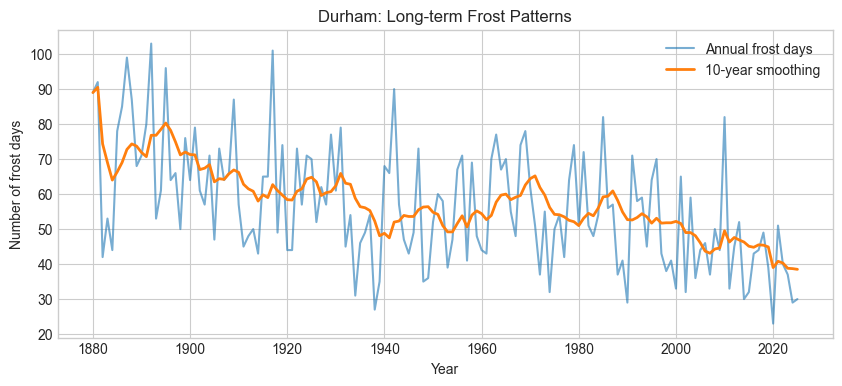

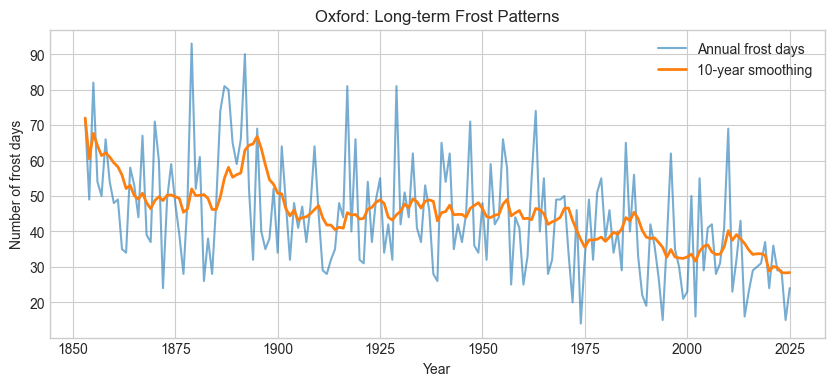

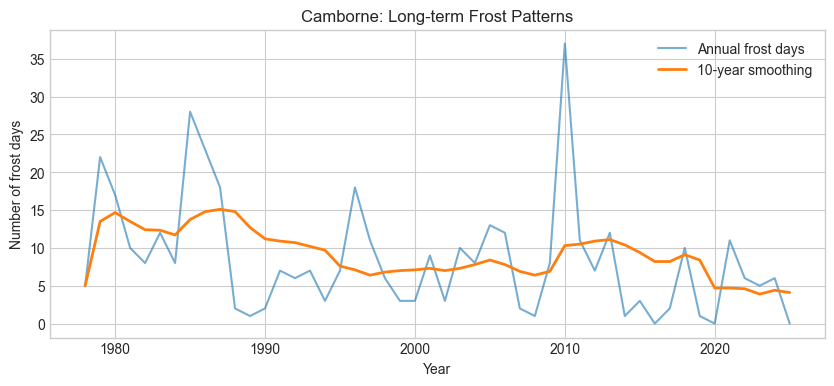

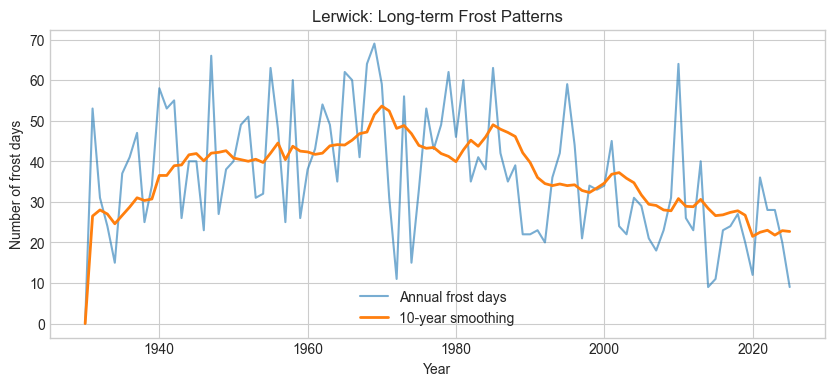

In [37]:
# Task 1: Frost day trends for four stations

selected_stations = ["Durham", "Oxford", "Camborne", "Lerwick"]

for station in selected_stations:
    
# filter data for the current station
    station_data = weather[weather["Location"] == station]
    
# compute yearly total frost days
    yearly_frost = (
        station_data.groupby("Year")["Frost"]
                    .sum()
                    .reset_index()
    )
    
    plt.figure(figsize=(10, 4))
    
# annual frost counts
    plt.plot(
        yearly_frost["Year"],
        yearly_frost["Frost"],
        alpha=0.6,
        label="Annual frost days"
    )
    
# smoothing to highlight long-term tendencies
    frost_smooth = yearly_frost["Frost"].rolling(10, min_periods=1).mean()
    plt.plot(
        yearly_frost["Year"],
        frost_smooth,
        linewidth=2,
        label="10-year smoothing"
    )
    
    plt.title(f"{station}: Long-term Frost Patterns")
    plt.xlabel("Year")
    plt.ylabel("Number of frost days")
    plt.legend()
    plt.show()

### Durham – Frost Trend

In Durham, frost days start at higher levels in the early years of the record and then decline steadily over time. Although there are occasional fluctuations, the long-term trend is clearly downward, with recent years showing fewer frost days compared to earlier periods.

### Oxford – Frost Trend

In Oxford, frost days fluctuate over many years, but the overall pattern shows a gradual decrease. Frost days are more frequent at the beginning of the record and become less common in later years. While short-term increases appear at times, the long-term trend is consistently downward.

### Camborne – Frost Trend

In Camborne, frost days are generally low throughout the record. Although slightly higher values appear in the earlier years, frost days decrease noticeably as time progresses. Despite some fluctuations, the overall trend is downward.

### Lerwick – Frost Trend

In Lerwick, frost days increase during the early years of the record but this rise does not persist. Frost days then decline gradually and remain lower in the more recent years. While short-term variations occur, the long-term trend is clearly downward.

### Overall Frost Comparison

Across all four stations, frost days show a clear long-term decrease, although the pace of this decline differs between locations. Some stations begin the record with noticeably higher frost levels, while others start lower, but all show a downward direction over time. Despite occasional short-term fluctuations, the overall pattern is consistent: frost days have become less frequent across all stations throughout the period observed.


## Part 2 — Trend Modelling: Maximum Temperature Analysis


## Step 1 – Preparing Data for Regression Analysis

The purpose of this step is to prepare the dataset for the regression model by first gathering all station files into a unified structure and then generating the required time and seasonality variables.

All `*data.csv` files in the working directory were automatically loaded, and each dataset was tagged with a station name extracted from the filename. This process allowed all 37 stations to be combined into a single data frame (`weather_all`).

Next, the `prepare_station` function was created to standardise the cleaning and preparation steps for every station.

This function filters the data for the selected station, removes observations with missing TMax values, and constructs a continuously increasing time index (`t`) measured in months.

To incorporate yearly seasonality into the regression model, sine and cosine terms were added for each observation. These variables allow the model to capture the natural cyclical temperature patterns observed throughout the year.

After completing these steps, a clean, consistent, and regression-ready dataset was obtained for all stations.

Missing TMax values were removed rather than imputed. This decision avoids the risk of artificially distorting the long-term trend or the seasonal pattern, which can occur when replacement values are introduced. Since the number of missing observations was very small, dropping these rows did not lead to meaningful data loss and allowed the regression model to be fitted more reliably.


In [38]:
# load all station CSV files in the folder
all_files = glob.glob("*data.csv")

# prepare an empty list to store each station's dataframe
station_dfs = []

for f in all_files:
# read one station's CSV file
    df_tmp = pd.read_csv(f)
    
# extract the station name from the filename
    name = f.replace("data.csv", "").lower()
    
# add a Location column to identify the station
    df_tmp["Location"] = name
    
# store the dataframe in the list
    station_dfs.append(df_tmp)

# combine all individual station dataframes into one
weather_all = pd.concat(station_dfs, ignore_index=True)


In [39]:
# select a single station and copy its data
def prepare_station(df, station_name):
    # filter rows belonging to the chosen station
    sub = df[df["Location"] == station_name].copy()
    
    # remove rows with missing TMax values
    sub = sub.dropna(subset=["TMax"])

    # create a continuous time index (in months)
    sub["t"] = (sub["Year"] - sub["Year"].min()) * 12 + (sub["Month"] - 1)

    # define seasonal frequency (1 cycle per year)
    omega = 2 * np.pi / 12
    
    # add sine term for annual seasonality
    sub["sin_t"] = np.sin(omega * sub["t"])
    
    # add cosine term for annual seasonality
    sub["cos_t"] = np.cos(omega * sub["t"])
    
    # return the cleaned and prepared dataset
    return sub

## Step 2 – Establishing the Linear Trend Model

In this step, a regression model was constructed to examine how maximum temperatures (TMax) change over time for each station.  
Because monthly temperature data exhibit strong seasonality, using only a time variable is not sufficient. Therefore, sine and cosine terms were included to capture the annual temperature cycle.

The regression model used is:

$$
TMax = \beta_0 + \beta_1 t + \beta_2 \sin(\omega t) + \beta_3 \cos(\omega t) + \varepsilon
$$

- **t** is the time index, increasing by one for each consecutive month.  
- **sin(ωt)** and **cos(ωt)** model the regular seasonal temperature cycle observed each year.  
- **β₁** is the long-term trend coefficient; a positive value indicates an upward temperature trend, while a negative value indicates a downward trend.

First, this model was fitted for each station using the `fit_trend_model` function.  
The residuals (the difference between observed and predicted values) were extracted and stored, as these will be used in the next step to generate bootstrap confidence intervals for the trend coefficient.

Afterwards, the same regression model was applied to all 37 stations, and the slope coefficient **β₁** was recorded for each location.  
These coefficients were compiled into a table to allow comparison of temperature trends across all stations.

In [40]:
# Regression model: fits TMax using trend + seasonality terms
def fit_trend_model(df):

    # Construct the design matrix X (t, sin(t), cos(t))
    X = np.column_stack((df["t"], df["sin_t"], df["cos_t"]))
    
    # Dependent variable: maximum temperature
    y = df["TMax"].values

    # Fit the linear regression model
    reg = LinearRegression().fit(X, y)

    # Predicted values from the fitted model
    y_pred = reg.predict(X)

    # Residuals (actual - predicted)
    residuals = y - y_pred

    # Return model + residuals for bootstrap
    return reg, residuals, y_pred

In [41]:
# List all station names in the combined dataset
all_station_names = weather_all["Location"].unique()

# Store (station, beta1) results
beta1_list = []

# Loop through all stations to fit the regression model
for st in all_station_names:
    
# Prepare cleaned and structured data for the station
    df_st = prepare_station(weather_all, st)

# Fit the regression model and obtain residuals
    reg, res, yhat = fit_trend_model(df_st)

# Extract the trend coefficient β₁
    beta1 = reg.coef_[0]

# Save results for the station
    beta1_list.append([st, beta1])

# Convert results into a dataframe
beta1_df = pd.DataFrame(beta1_list, columns=["Station", "Beta1"])

# Display the table of trend coefficients
beta1_df


,Station,Beta1
0,eastbourne,0.003193
1,southampton,0.000527
2,dunstaffnage,0.002580
3,aberporth,0.001004
4,paisley,0.001919
5,durham,0.000871
6,braemar,0.001936
7,stornoway,0.000592
8,heathrow,0.002614
9,chivenor,0.001583


### Interpretation Note — Eastbourne Trend Plot

The fitted model shows a clear upward long-term trend superimposed on a strong annual seasonal cycle, indicating that Eastbourne is among the fastest-warming stations.

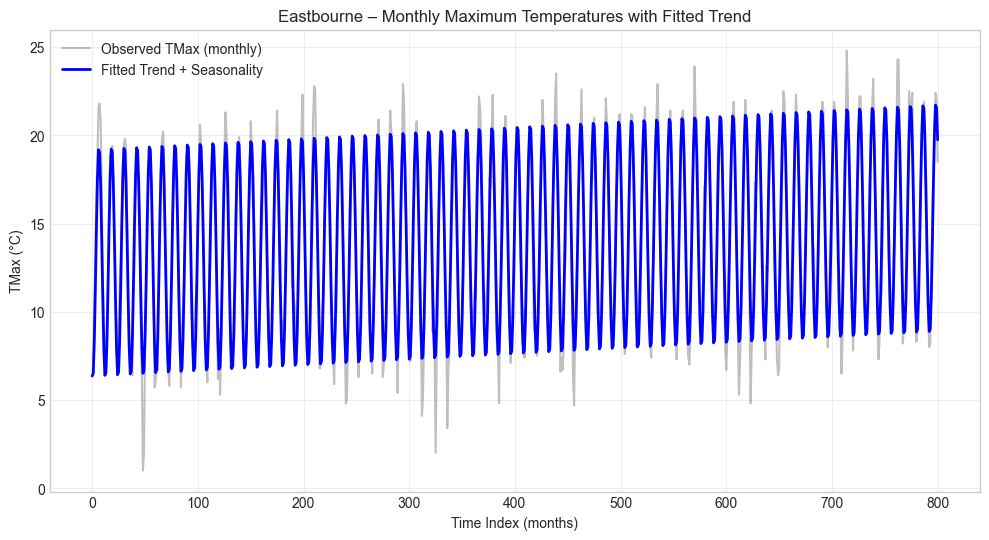

In [42]:
# Load Eastbourne data
df_ea_raw = pd.read_csv("eastbournedata.csv")

# Prepare station using the Task 2 function
df_ea = prepare_station(weather_all, "eastbourne")

# Fit trend + seasonality regression model
reg_ea, residuals_ea, y_hat_ea = fit_trend_model(df_ea)

# Plot the monthly TMax with fitted trend line
plt.figure(figsize=(12,6))

plt.plot(df_ea["t"], df_ea["TMax"], color="gray", alpha=0.5, label="Observed TMax (monthly)")
plt.plot(df_ea["t"], y_hat_ea, color="blue", linewidth=2, label="Fitted Trend + Seasonality")

plt.title("Eastbourne – Monthly Maximum Temperatures with Fitted Trend")
plt.xlabel("Time Index (months)")
plt.ylabel("TMax (°C)")
plt.grid(alpha=0.3)
plt.legend()

plt.show()


### Interpretation Note — Armagh Trend Plot

In Armagh, the fitted trend appears much flatter, with seasonality dominating the time series. This highlights that the warming rate here is notably weaker than in southern coastal stations.

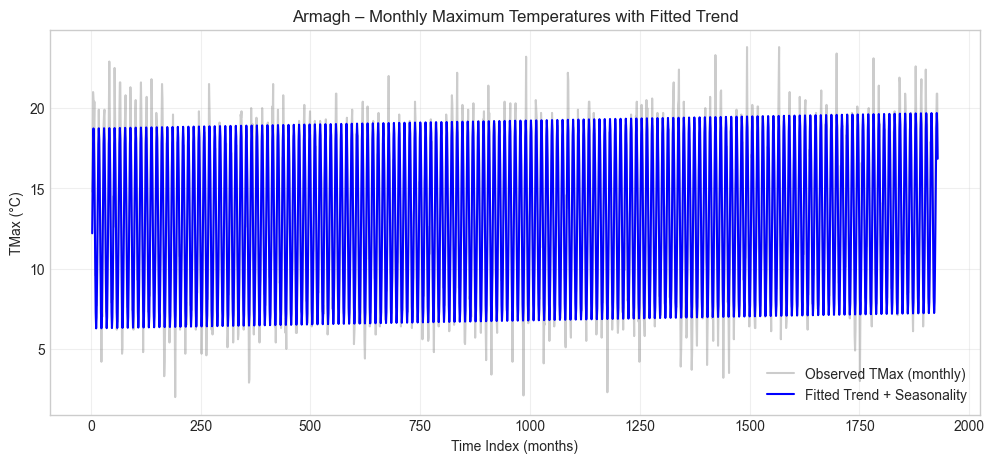

In [43]:
# Load Armagh station data
df_arm = pd.read_csv("armaghdata.csv")

# Prepare monthly data and add time + seasonality terms
df_arm = prepare_station(weather_all, "armagh")

# Fit trend + seasonality regression model
reg_arm, residuals_arm, y_hat_arm = fit_trend_model(df_arm)

# Plot monthly Tmax time series + fitted model
plt.figure(figsize=(12,5))

# Observed data
plt.plot(df_arm["t"], df_arm["TMax"], color="grey", alpha=0.4, label="Observed TMax (monthly)")

# Fitted model
plt.plot(df_arm["t"], y_hat_arm, color="blue", linewidth=1.5, label="Fitted Trend + Seasonality")

plt.title("Armagh – Monthly Maximum Temperatures with Fitted Trend")
plt.xlabel("Time Index (months)")
plt.ylabel("TMax (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


### Interpretation of Trend Coefficients (β₁)

The slope coefficients **(β₁)** obtained for all 37 stations are positive, indicating a long-term upward trend in maximum temperatures at every location. Although the magnitude of these coefficients varies across stations, some regions show a more pronounced increase **(e.g., Whitby, Cardiff, Eastbourne)**, whereas others exhibit a more modest warming **(e.g., Armagh, Lerwick, Tiree)**.

These findings suggest that the rate of temperature increase is not spatially uniform; certain areas are warming faster than others. The consistently positive β₁ values across all stations provide clear evidence of rising maximum temperatures throughout the United Kingdom. However, these coefficients represent only the estimated direction and strength of the trend. The reliability and precision of these estimates will be evaluated more rigorously in the next step using bootstrap confidence intervals.


## Step 3 – Residual Bootstrap Method for the Trend Coefficient (β₁)

In this step, the confidence interval for the slope coefficient **(β₁)** in the trend model for each station was calculated using the **residual bootstrap method**. This approach repeatedly resamples the data to capture the model’s variability and uncertainty.

First, a regression model was fitted for each station, and the **residuals**—defined as the difference between the model’s predicted TMax values and the actual observations—were obtained.

During the bootstrap procedure, these residuals were **randomly resampled with replacement**. For each bootstrap sample, the resampled residuals were added to the model’s fitted values to create a new **synthetic TMax series**. The regression model was then refitted on this synthetic dataset, and the **β₁ coefficient** was stored.

After repeating this process many times, a **bootstrap distribution of β₁** was obtained. The **2.5th and 97.5th percentiles** of this distribution were taken as the bounds of the **95% confidence interval**.

This method allows the reliability of the trend coefficient to be assessed more accurately, as it is based directly on the observed data rather than relying on strict parametric assumptions.

In [44]:
def residual_bootstrap_beta1(df, repeats=1000):

    # Trend + seasonality regression (model, residuals, y_hat)
    reg, residuals, y_hat = fit_trend_model(df)

    # Design matrix X
    X = np.column_stack((df["t"], df["sin_t"], df["cos_t"]))
    y = df["TMax"].values

    beta1_list = []

    for _ in range(repeats):

        # Residual bootstrap
        eps_star = np.random.choice(residuals, size=len(residuals), replace=True)
        y_star = y_hat + eps_star

        # Refit regression on bootstrap y*
        reg_star = LinearRegression().fit(X, y_star)

        # Store bootstrap slope β1
        beta1_list.append(reg_star.coef_[0])

    return np.array(beta1_list)

all_station_names = weather_all["Location"].unique()
results = []

for st in all_station_names:
    df_st = prepare_station(weather_all, st)

    # residual bootstrap distribution of beta1
    boot = residual_bootstrap_beta1(df_st, repeats=1000)

    ci_low, ci_up = np.quantile(boot, [0.025, 0.975])
    beta1_hat = fit_trend_model(df_st)[0].coef_[0]

    results.append([st, beta1_hat, ci_low, ci_up])

ci_df = pd.DataFrame(results, columns=["Station", "Beta1", "CI_low", "CI_up"])
ci_df


,Station,Beta1,CI_low,CI_up
0,eastbourne,0.003193,0.002788,0.003620
1,southampton,0.000527,0.000381,0.000669
2,dunstaffnage,0.002580,0.002122,0.003065
3,aberporth,0.001004,0.000740,0.001285
4,paisley,0.001919,0.001360,0.002517
5,durham,0.000871,0.000723,0.001029
6,braemar,0.001936,0.001422,0.002405
7,stornoway,0.000592,0.000502,0.000689
8,heathrow,0.002614,0.002233,0.003026
9,chivenor,0.001583,0.001162,0.001985


### Evaluating Bootstrap Confidence Intervals

The bootstrap results confirm that the findings from Step 2—where all β₁ coefficients were positive—are statistically reliable.

For every station, the 95% confidence interval for β₁ remains entirely above zero. This indicates that the observed long-term warming trends cannot be attributed to random variability and are statistically significant.

The width of the confidence intervals varies noticeably across stations:

- **Stations with narrow intervals** (e.g., Heathrow, Yeovilton, Cambridge) provide more stable and precise trend estimates.
- **Stations with wider intervals** (e.g., Whitby, Cwmystwyth) exhibit greater uncertainty, suggesting more variability in their long-term temperature patterns.

This analysis evaluates not only the direction of the β₁ coefficient but also the degree of confidence we have in its value. As a result, the conclusions regarding maximum temperature trends become more robust, with a clearer understanding of the associated uncertainty.

Because bootstrap estimates depend on random resampling, the exact confidence interval bounds can show minor variation between runs. The values discussed here correspond to a single realisation of the bootstrap procedure.

### Boxplot of Warming Trends (β₁) for All 37 Stations

The boxplot below summarises the distribution of the estimated trend coefficients (β₁) across all 37 stations.
The entire distribution lies above zero, reinforcing the conclusion that maximum temperatures are increasing nationwide.
The spread of the boxplot shows that the magnitude of the warming trend varies across locations, consistent with earlier comparisons of individual confidence intervals.

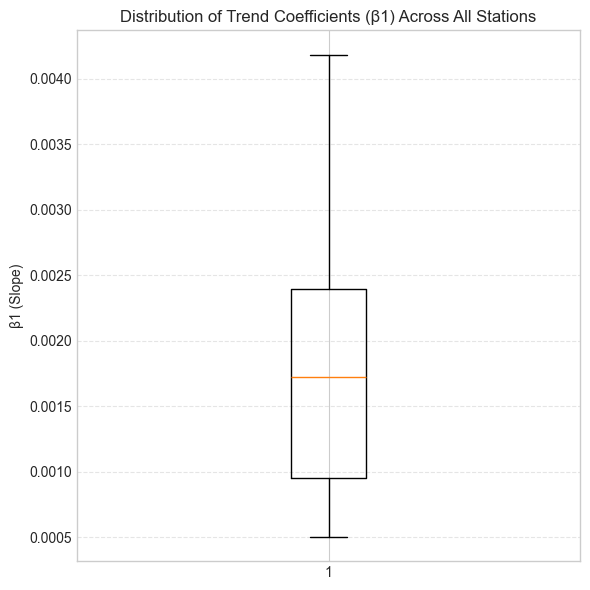

In [45]:
plt.figure(figsize=(6, 6))

plt.boxplot(ci_df["Beta1"], vert=True)

plt.title("Distribution of Trend Coefficients (β1) Across All Stations")
plt.ylabel("β1 (Slope)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Step 4 – Prediction Interval for August 2075 Using the Residual Bootstrap Method

In this step, a prediction interval for the maximum temperature (TMax) in August 2075 was obtained for the selected stations using the residual bootstrap method.

This approach accounts for both the uncertainty in the regression coefficients and the natural variability present in the temperature data.

First, a regression model incorporating both trend and seasonality was fitted for each station, and the residuals—defined as the differences between the model’s predicted values and the actual observations—were obtained.

The residual bootstrap method was then applied.  
In this method, the residuals were resampled with replacement and added to the model’s fitted values to generate new synthetic temperature series.  
The model was refitted on each synthetic series, and a prediction for August 2075 was calculated.  

Repeating this process many times produced a bootstrap distribution of future temperature predictions.

The 2.5th and 97.5th percentiles of this distribution were taken to form a 95% prediction interval for August 2075.  
This interval represents the likely range within which the future maximum temperature may fall.

By accounting for both model uncertainty and natural variability in the data, this method provides a more robust and reliable evaluation of future temperature projections.


In [46]:
# FUNCTION: Bootstrap Prediction Interval for a Station

def bootstrap_predict_PI(df, year=2075, month=8, repeats=2000):

# 1. Create design matrix (trend + seasonality)
    X = np.column_stack((df["t"], df["sin_t"], df["cos_t"]))
    y = df["TMax"].values

# 2. Fit initial regression model
    reg = LinearRegression().fit(X, y)
    y_hat = reg.predict(X)
    residuals = y - y_hat

# 3. Create time index for future month
    t_star = (year - df["Year"].min()) * 12 + (month - 1)

# design matrix for prediction point
    X_star = np.array([
        t_star,
        np.sin(2*np.pi/12 * t_star),
        np.cos(2*np.pi/12 * t_star)
    ]).reshape(1, -1)

# 4. Point prediction
    point_pred = reg.predict(X_star)[0]

# 5. Bootstrap predictions
    predictions = []

    for _ in range(repeats):

# resample residuals
        res_sample = np.random.choice(residuals, size=len(residuals), replace=True)

# create bootstrap y
        y_boot = y_hat + res_sample

# refit regression
        reg_b = LinearRegression().fit(X, y_boot)
        y_boot_hat = reg_b.predict(X)

# bootstrap residuals
        res_boot = y_boot - y_boot_hat

# pick a bootstrap residual for future month
        eps_star = np.random.choice(res_boot)

# final bootstrap prediction
        y_star_boot = reg_b.predict(X_star)[0] + eps_star
        predictions.append(y_star_boot)

    predictions = np.array(predictions)

# 95% prediction interval
    PI_low, PI_up = np.quantile(predictions, [0.025, 0.975])

    return point_pred, PI_low, PI_up, predictions

eastbourne = prepare_station(weather_all, "eastbourne")
armagh = prepare_station(weather_all, "armagh")

In [47]:
pred_e, pi_low_e, pi_up_e, boot_e = bootstrap_predict_PI(eastbourne, year=2075, month=8)
pred_a, pi_low_a, pi_up_a, boot_a = bootstrap_predict_PI(armagh, year=2075, month=8)

print("Eastbourne – August 2075")
print(f"Point prediction: {pred_e}")
print(f"95% PI: [{pi_low_e}, {pi_up_e}]\n")

print("Armagh – August 2075")
print(f"Point prediction: {pred_a}")
print(f"95% PI: [{pi_low_a}, {pi_up_a}]")


Eastbourne – August 2075
Point prediction: 23.482840783816513
95% PI: [20.942625028655115, 26.07544344997513]

Armagh – August 2075
Point prediction: 19.312309360720658
95% PI: [16.482438571493667, 22.037577918911822]


### Interpretation of Prediction Intervals (Eastbourne vs Armagh)

The predicted maximum temperature for August 2075 is **23.48°C for Eastbourne** and **19.31°C for Armagh**. These values are fully consistent with the long-term trend coefficients obtained in Step 2: Eastbourne is among the fastest-warming stations in the UK (β₁ ≈ 0.00319), whereas Armagh shows one of the slowest warming rates (β₁ ≈ 0.00050).

The 95% prediction intervals obtained from the residual bootstrap are:

- **Eastbourne:** 20.94°C – 26.07°C  
- **Armagh:** 16.48°C – 22.03°C

These results reveal three key insights:

1. **Regional warming differences are substantial.**  
   Both the point prediction and prediction interval for Eastbourne are noticeably higher than those for Armagh. This indicates that the temperature gap between fast-warming southern coastal regions and slower-warming northern inland regions is likely to widen in the future.

2. **The prediction intervals are relatively wide.**  
   This reflects the influence of natural climate variability and highlights that future temperatures should be interpreted as a plausible range rather than a precise value.

3. **Both locations are projected to experience markedly warmer conditions.**  
   Even the lower bounds of the prediction intervals (Eastbourne: 20.68°C, Armagh: 16.59°C) lie well above current historical averages, providing strong statistical evidence of continued long-term warming.

### Bootstrap Prediction Distributions for August 2075 (Eastbourne vs Armagh)

The histogram below visually supports the prediction interval analysis.  
Eastbourne’s bootstrap distribution is clearly shifted toward higher temperatures, while Armagh’s predictions cluster at noticeably lower values.

This visual separation aligns with the numerical results: Eastbourne is projected to experience considerably warmer conditions than Armagh by 2075, reinforcing the regional warming differences identified in the analysis.

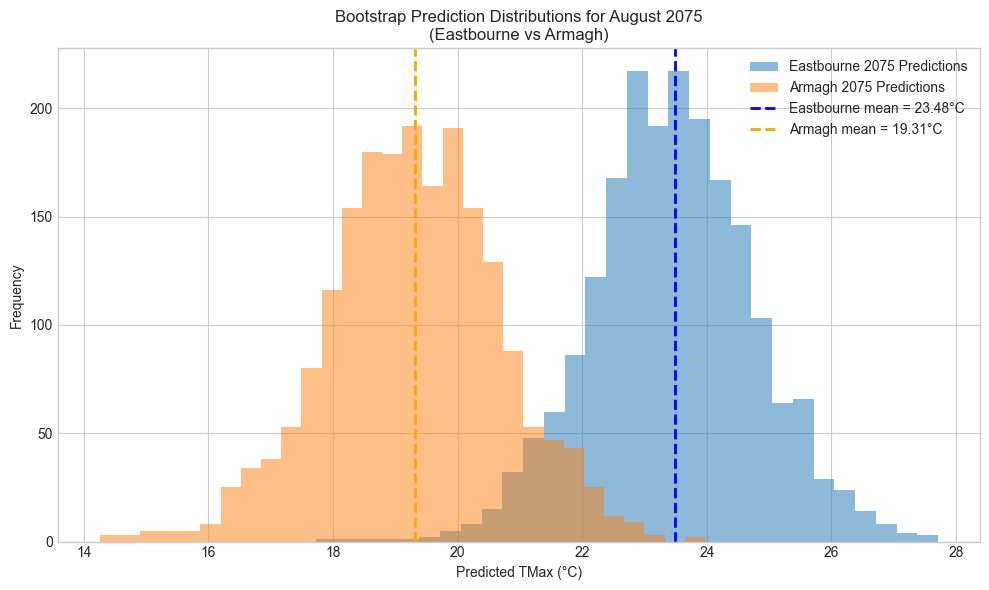

In [48]:
plt.figure(figsize=(10,6))

# Eastbourne histogram
plt.hist(boot_e, bins=30, alpha=0.5, label="Eastbourne 2075 Predictions")

# Armagh histogram
plt.hist(boot_a, bins=30, alpha=0.5, label="Armagh 2075 Predictions")

# Add vertical lines for point predictions
plt.axvline(pred_e, color="blue", linestyle="--", linewidth=2,
            label=f"Eastbourne mean = {pred_e:.2f}°C")

plt.axvline(pred_a, color="orange", linestyle="--", linewidth=2,
            label=f"Armagh mean = {pred_a:.2f}°C")

plt.title("Bootstrap Prediction Distributions for August 2075\n(Eastbourne vs Armagh)")
plt.xlabel("Predicted TMax (°C)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


## Part 3 — Hypothesis Testing: Changing Pattern of Air Frost Days


## Step 1A – Preparing the Winter Frost-by-Decade Table

In this step, the contingency table of frost days used in the chi-square test was prepared.

First, the total number of days in each month (`DaysInMonth`) was added to the dataset. This was necessary for calculating the number of frost-free days within each month, based on the provided monthly frost counts.

Missing frost values were completed using the average frost value for that specific month (e.g., missing January values were replaced using the average of all observed January frost values). Frost shows strong seasonality, so filling all missing values with a single overall mean would distort this structure. Removing missing rows would also lead to unnecessary loss of entire years. Using monthly averages preserves seasonal patterns while keeping the dataset as complete as possible. A final `dropna` step was included as a safeguard to ensure that any remaining invalid or non-numeric frost entries were removed before constructing the contingency table.

For the decade analysis, only the DJF (December–January–February) months were used. Since most frost occurs during these months, focusing on winter provides a clearer view of long-term changes. Although using the full year is possible, restricting the decade analysis to winter months allows the underlying trend in frost days to be observed more clearly.

For each month, two categories were constructed:

- **Frost_days** = Frost  
- **NoFrost_days** = DaysInMonth − Frost  

Finally, years were assigned to their corresponding decade, and frost/non-frost days were aggregated within each decade. The resulting **Decade × (Frost / NoFrost)** table serves as the observed contingency table for the chi-square independence test performed in Step 2.


In [49]:
# Step 1A – Preparing the Winter (DJF) Frost-by-Decade Crosstab

# Add number of days in each month
def add_days_in_month(df):
    # Days per month (non-leap year)
    days = {
        1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
        7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
    }
    df["DaysInMonth"] = df["Month"].map(days)
    return df


# Impute missing frost values separately for each month
def impute_frost_month(df, month):
    sub = df[df["Month"] == month].copy()
    
    if sub["Frost"].isna().all():
        return sub
    
    monthly_mean = sub["Frost"].mean()
    sub["Frost"] = sub["Frost"].fillna(monthly_mean)
    
    return sub


# Create DJF frost-by-decade table for a single station
def prepare_frost_decade_table(df_station):
    df_station = add_days_in_month(df_station)

    winter = df_station[df_station["Month"].isin([12, 1, 2])].copy()

    winter_list = []
    for m in [12, 1, 2]:
        winter_list.append(impute_frost_month(df_station, m))

    winter = pd.concat(winter_list)

    winter = winter.dropna(subset=["Frost"])
    winter["Frost"] = winter["Frost"].astype(float)

    winter["Frost_days"] = winter["Frost"]
    winter["NoFrost_days"] = winter["DaysInMonth"] - winter["Frost"]

    winter["Decade"] = (winter["Year"] // 10) * 10

    decade_table = winter.groupby("Decade")[["Frost_days", "NoFrost_days"]].sum()

    return decade_table

## Step 1B – Preparing the Year-Level Frost Table (All Months)

A second contingency table was created at the yearly level to complement the decade-based winter analysis. The same preprocessing steps were applied as before: monthly frost values were completed using month-specific averages, `DaysInMonth` was added to calculate non-frost days, and a final `dropna` step ensured that only valid frost values remained. 

Unlike the decade table, this version uses **all months of the year**, allowing year-to-year variation in frost days to be examined without restricting the analysis to winter. Monthly frost and non-frost days were summed within each year, resulting in the **Year × (Frost / NoFrost)** contingency table used for the second chi-square test.


In [50]:
# STEP 1B: Prepare Year × FrostDays crosstab (all months)

def prepare_frost_year_table(df_station):
# Add days in month
    df_station = add_days_in_month(df_station)

# Impute missing values separately for each month (1–12)
    imputed_list = []
    for m in range(1, 13):
        imputed_list.append(impute_frost_month(df_station, m))
    df_station = pd.concat(imputed_list)

# Remove any remaining missing frost values
    df_station = df_station.dropna(subset=["Frost"])
    df_station["Frost"] = df_station["Frost"].astype(float)

# Calculate frost / nofrost days
    df_station["Frost_days"] = df_station["Frost"]
    df_station["NoFrost_days"] = df_station["DaysInMonth"] - df_station["Frost"]

# Group into YEAR table
    year_table = df_station.groupby("Year")[["Frost_days", "NoFrost_days"]].sum()

    return year_table


### Oxford – Frost Tables (Decade and Year)



In [51]:
df_ox = pd.read_csv("oxforddata.csv")

# Display the winter (DJF) frost-by-decade table for Oxford
# This table is used in the decade-level chi-square test
print("OXFORD — Winter-only (DJF) Decade × FrostDays:")
display(prepare_frost_decade_table(df_ox))

# Display the annual frost-by-year table for Oxford
# This table is used in the year-level chi-square test
print("\nOXFORD — Year × FrostDays:")
display(prepare_frost_year_table(df_ox))

OXFORD — Winter-only (DJF) Decade × FrostDays:


,Frost_days,NoFrost_days
Decade,,
1850,253.000000,377.000000
1860,265.631579,634.368421
1870,320.000000,580.000000
1880,324.000000,576.000000
1890,323.000000,577.000000
1900,285.000000,615.000000
1910,240.000000,660.000000
1920,236.000000,664.000000
1930,266.000000,634.000000



OXFORD — Year × FrostDays:


,Frost_days,NoFrost_days
Year,,
1853,72.0,293.0
1854,49.0,316.0
1855,82.0,283.0
1856,54.0,311.0
1857,50.0,315.0
...,...,...
2021,36.0,329.0
2022,29.0,336.0
2023,29.0,336.0


### Interpretation of the Oxford Frost Tables

The tables for Oxford show the expected structure of the processed frost data.  
At the decade level (winter-only), frost days gradually change across decades with a visible drop in the most recent decade.  
At the yearly level (all months), the variability is larger, reflecting year-to-year fluctuations that are not visible in the decade aggregation.  
A detailed statistical interpretation is carried out in Step 2 using chi-square tests.


### Durham – Frost Tables (Decade and Year)


In [52]:
df_du = pd.read_csv("durhamdata.csv")

# Display the winter (DJF) frost-by-decade table for Durham
# Used in the decade-level chi-square test
print("DURHAM — Winter-only (DJF) Decade × FrostDays:")
display(prepare_frost_decade_table(df_du))

# Display the annual frost-by-year table for Durham
# Used in the year-level chi-square test
print("\nDURHAM — Year × FrostDays:")
display(prepare_frost_year_table(df_du))


DURHAM — Winter-only (DJF) Decade × FrostDays:


,Frost_days,NoFrost_days
Decade,,
1880,421.319444,478.680556
1890,415.000000,485.000000
1900,393.000000,507.000000
1910,315.000000,585.000000
1920,329.000000,571.000000
1930,294.000000,606.000000
1940,358.000000,542.000000
1950,359.000000,541.000000
1960,420.000000,480.000000



DURHAM — Year × FrostDays:


,Frost_days,NoFrost_days
Year,,
1880,89.000000,276.000000
1881,92.000000,273.000000
1882,42.000000,323.000000
1883,63.319444,301.680556
1884,44.000000,321.000000
...,...,...
2021,51.000000,314.000000
2022,40.000000,325.000000
2023,37.000000,328.000000


### Interpretation of the Durham Frost Tables

The processed tables for Durham follow the same structure as in the Oxford example.  
Winter-only decade values show the aggregated frost and non-frost days across decades, while the year-level table shows larger year-to-year variability when all months are included.  
Further interpretation is provided in the chi-square analysis in Step 2.

### Camborne – Frost Tables (Decade and Year)


In [53]:
df_ca = pd.read_csv("cambornedata.csv")

# Display the winter (DJF) frost-by-decade table for Camborne
# Used in the decade-level chi-square independence test
print("CAMBORNE — Winter-only (DJF) Decade × FrostDays:")
display(prepare_frost_decade_table(df_ca))

# Display the annual frost-by-year table for Camborne
# Used in the year-level chi-square independence test
print("\nCAMBORNE — Year × FrostDays:")
display(prepare_frost_year_table(df_ca))

CAMBORNE — Winter-only (DJF) Decade × FrostDays:


,Frost_days,NoFrost_days
Decade,,
1970,25.0,96.0
1980,102.0,798.0
1990,61.0,839.0
2000,57.0,843.0
2010,62.0,838.0
2020,26.0,483.0



CAMBORNE — Year × FrostDays:


,Frost_days,NoFrost_days
Year,,
1978,5.0,117.0
1979,22.0,343.0
1980,17.0,348.0
1981,10.0,355.0
1982,8.0,357.0
1983,12.0,353.0
1984,8.0,357.0
1985,28.0,337.0
1986,23.0,342.0


### Interpretation of the Camborne Frost Tables

The Camborne tables show the same processed structure as the previous stations.  
Because this station has a shorter historical record, the decade table includes fewer decades, but the year-level table still captures the full month-by-month variation.  
As before, detailed interpretation is deferred to the chi-square analysis in Step 2.

## Step 2A – Chi-Square Independence Test (Winter Decade Table)

In this step, a chi-square test of independence was applied to the decade-level contingency table for the winter months (DJF) to assess whether the number of frost days has changed over time. The hypotheses of the test are:

- **H₀:** The distribution of frost days does not change over time (frost and decade are independent).  
- **H₁:** The distribution of frost days changes over time (frost and decade are related).

The function first checks whether the station has data for more than one decade; if only a single decade is present, the test cannot be performed. For valid tables, `chi2_contingency` compares the observed values with the expected values under the independence assumption and computes the chi-square statistic, p-value, and degrees of freedom.

To complement the chi-square test, **Cramer's V** was also calculated to quantify the strength of the association. This provides insight not only into whether a relationship exists between frost days and time but also into how strong that relationship is.

In [54]:
def chi_square_frost_decade(df_station):

# Build the winter (DJF) frost-by-decade table
    decade_table = prepare_frost_decade_table(df_station)

# If the station has fewer than 2 decades, the test cannot be applied
    if decade_table.shape[0] < 2:
        return None, None, None, None, decade_table, None

# Run chi-square test on the observed decade table
    chi2, p, dof, expected = chi2_contingency(decade_table)

# Compute Cramer's V (effect size)
    n = decade_table.values.sum()
    r, k = decade_table.shape
    phi2 = chi2 / n
    cramer_v = np.sqrt(phi2 / min(k - 1, r - 1))

# Return chi-square results and the tables used
    return chi2, p, dof, expected, decade_table, cramer_v



The function below applies the winter (DJF) decade-level chi-square test to all 37 stations and compiles their chi-square statistics, p-values, and Cramer's V values into a single summary table.


In [55]:
# Get all CSV files in the current working directory
# These files correspond to the 37 individual weather stations
file_list = glob.glob("*.csv")

file_list

['eastbournedata.csv',
 'southamptondata.csv',
 'dunstaffnagedata.csv',
 'aberporthdata.csv',
 'paisleydata.csv',
 'ALL-WEATHER-STATIONS.csv',
 'durhamdata.csv',
 'braemardata.csv',
 'stornowaydata.csv',
 'heathrowdata.csv',
 'chivenordata.csv',
 'manstondata.csv',
 'eskdalemuirdata.csv',
 'newtonriggdata.csv',
 'shawburydata.csv',
 'yeoviltondata.csv',
 'ballypatrickdata.csv',
 'suttonboningtondata.csv',
 'leucharsdata.csv',
 'ringwaydata.csv',
 'cardiffdata.csv',
 'bradforddata.csv',
 'nairndata.csv',
 'wickairportdata.csv',
 'cwmystwythdata.csv',
 'cambornedata.csv',
 'hurndata.csv',
 'tireedata.csv',
 'valleydata.csv',
 'lowestoftdata.csv',
 'whitbydata.csv',
 'sheffielddata.csv',
 'armaghdata.csv',
 'lerwickdata.csv',
 'cambridgedata.csv',
 'oxforddata.csv',
 'waddingtondata.csv',
 'rossonwyedata.csv']

In [56]:
def run_chi_square_all_stations(file_list):
    results = []

    for file in file_list:
        # Skip the combined dataset (not used for station-level analysis)
        if "ALL-WEATHER-STATIONS" in file:
            continue

        df = pd.read_csv(file)

        # Apply the chi-square test for the winter (DJF) decade table
        chi2, p, dof, expected, tbl, cramer_v = chi_square_frost_decade(df)

        # Extract station name from the file name
        station_name = file.replace(".csv", "")

        # Store the main chi-square outputs for comparison
        results.append({
            "Station": station_name,
            "Chi2": chi2,
            "p_value": p,
            "CramerV": cramer_v
        })

    return pd.DataFrame(results)


In [57]:
summary_decade = run_chi_square_all_stations(file_list)
summary_decade


,Station,Chi2,p_value,CramerV
0,eastbournedata,80.317855,1.186500e-14,0.115709
1,southamptondata,128.758216,3.720744e-20,0.099107
2,dunstaffnagedata,22.525295,4.159013e-04,0.068080
3,aberporthdata,120.988976,2.071491e-22,0.126015
4,paisleydata,63.853592,7.393296e-12,0.116078
5,durhamdata,179.743327,7.299329e-31,0.117096
6,braemardata,23.852834,1.209227e-03,0.063057
7,stornowaydata,332.167866,1.116581e-61,0.155825
8,heathrowdata,120.701286,2.375224e-22,0.131416
9,chivenordata,3.129956,8.727256e-01,0.022344


### Decade-Level Results Across All Stations

*A bar chart was included to summarise the variation in Cramer's V across all 37 stations at the decade level, allowing a clear comparison of the strength of association between frost days and time.*

Across all 37 stations, the chi-square test results show that almost all locations have a highly significant p-value, indicating strong statistical evidence that frost days have changed over time. Only one or two stations **(e.g., Chivenor)** show no detectable change.

Although significance is widespread, Cramer's V values remain small **(approximately 0.07–0.16)**, meaning the strength of the association is generally weak to moderate. This indicates that while long-term changes in frost frequency are present across the UK, the magnitude of these changes varies between stations and is overall relatively modest.

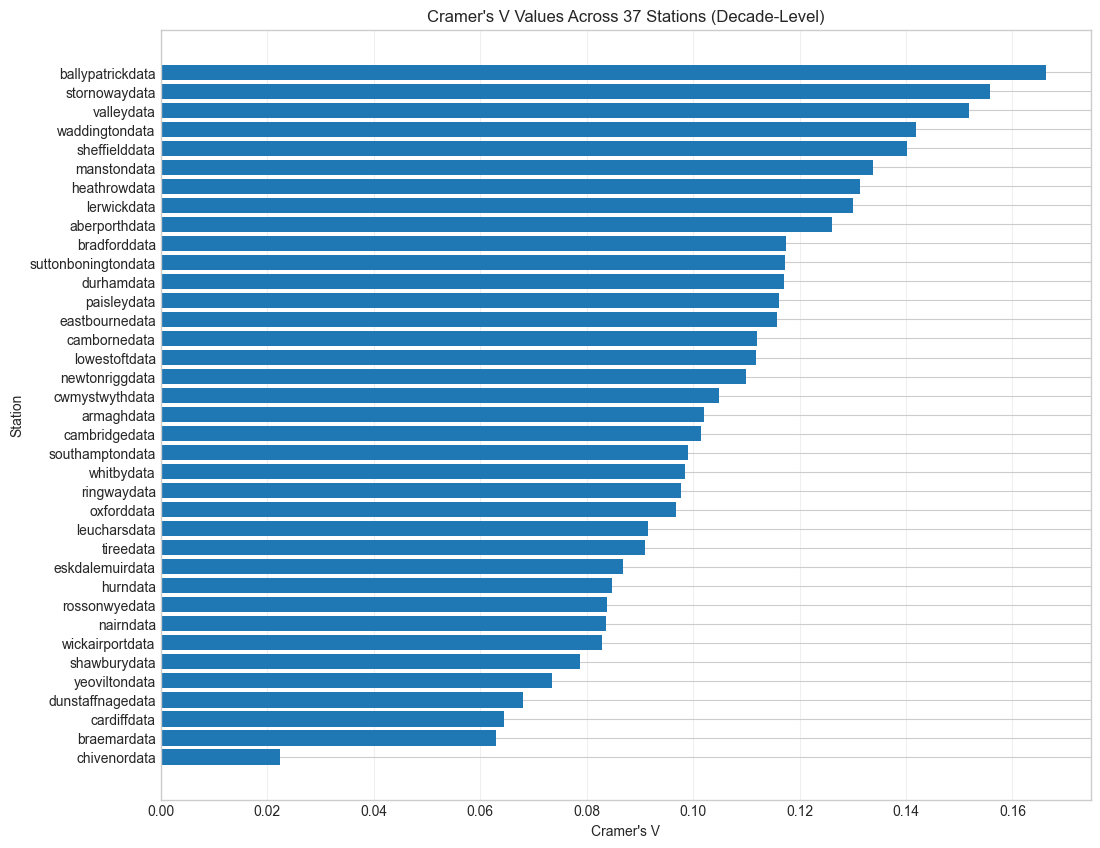

In [58]:
summary_decade_sorted = summary_decade.sort_values("CramerV", ascending=False)

plt.figure(figsize=(12,10))
plt.barh(summary_decade_sorted["Station"], summary_decade_sorted["CramerV"])
plt.title("Cramer's V Values Across 37 Stations (Decade-Level)")
plt.xlabel("Cramer's V")
plt.ylabel("Station")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()

plt.show()


### Chi-square Test Results for Oxford (Winter Decade Table)

This code performs a chi-square test of independence on the decade-level frost table for the winter months (DJF) for the Oxford station. The calculated chi-square statistic, p-value, degrees of freedom, and Cramer's V indicate the strength of the statistical evidence that frost days have changed over time.


In [59]:
df_ox = pd.read_csv("oxforddata.csv")

# Run the chi-square test on Oxford’s winter (DJF) decade-level frost table
chi2_d, p_d, dof_d, expected_d, obs_decade_ox, cramer_d = chi_square_frost_decade(df_ox)

# Display chi-square test results for Oxford
print("Oxford – Decade × FrostDays chi-square results:")
print(f"Chi-square: {chi2_d:.3f}")
print(f"P-value: {p_d:.3e}")
print(f"Degrees of freedom: {dof_d}")
print(f"Cramer's V: {cramer_d:.3f}")

Oxford – Decade × FrostDays chi-square results:
Chi-square: 145.651
P-value: 1.732e-22
Degrees of freedom: 17
Cramer's V: 0.097


The chi-square test shows a highly significant result (p < 0.001), indicating that the distribution of frost days in Oxford has changed across decades. However, the effect size is small (Cramer's V ≈ 0.10), suggesting that although the change is statistically significant, the strength of the association is weak.


In [60]:
# Load Oxford data
df_ox = pd.read_csv("oxforddata.csv")

# Run chi-square for Oxford (winter decade table)
chi2_ox, p_ox, dof_ox, expected_ox, obs_ox, cramer_ox = chi_square_frost_decade(df_ox)

# Display expected table for Oxford
expected_df_ox = pd.DataFrame(
    expected_ox,
    index=obs_ox.index,
    columns=obs_ox.columns
)

print("Oxford – Expected counts under independence:")
display(expected_df_ox)


Oxford – Expected counts under independence:


,Frost_days,NoFrost_days
Decade,,
1850,195.362500,434.637500
1860,279.089286,620.910714
1870,279.089286,620.910714
1880,279.089286,620.910714
1890,279.089286,620.910714
1900,279.089286,620.910714
1910,279.089286,620.910714
1920,279.089286,620.910714
1930,279.089286,620.910714


### Interpretation of the Expected Counts (Decade × FrostDays)

The table above shows the expected number of frost and non-frost days for each decade under the assumption that frost days and decade are independent. These values represent what the distribution would look like if there were no change over time.
Comparing these expected counts with the observed values (shown earlier) allows the chi-square test to quantify how much the actual data deviate from the independence model.

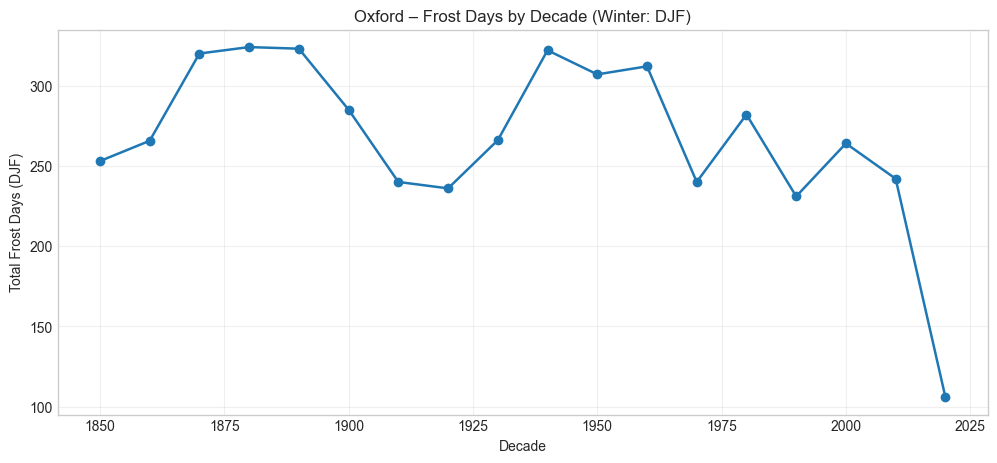

In [61]:
# Load Oxford data
df_ox = pd.read_csv("oxforddata.csv")

# Prepare the decade-level frost table
decade_table_ox = prepare_frost_decade_table(df_ox)

# Plot frost days aggregated by decade (DJF only)
plt.figure(figsize=(12,5))
plt.plot(decade_table_ox.index, decade_table_ox["Frost_days"], marker='o', linewidth=1.8)

plt.title("Oxford – Frost Days by Decade (Winter: DJF)")
plt.xlabel("Decade")
plt.ylabel("Total Frost Days (DJF)")
plt.grid(alpha=0.3)

plt.show()


The plot illustrates how Oxford’s winter frost totals vary across decades.


## Step 2B - Chi-Square Independence Test (Year-Level Analysis)

This function applies the same chi-square independence test to the annual frost table, using all months of the year instead of only winter. The test evaluates whether the distribution of frost and no-frost days varies across individual years and calculates Cramer’s V to quantify the strength of this relationship.


In [62]:
def chi_square_frost_year(df_station):

# Build the Year × FrostDays contingency table
    year_table = prepare_frost_year_table(df_station)

# If the station contains fewer than two years, the test cannot be performed
    if year_table.shape[0] < 2:
        return None, None, None, None, year_table, None

# Run the chi-square independence test
    chi2, p, dof, expected = chi2_contingency(year_table)

# Compute Cramer's V to assess effect size
    n = year_table.values.sum()
    r, k = year_table.shape
    phi2 = chi2 / n
    cramer_v = np.sqrt(phi2 / min(k - 1, r - 1))

# Return all outputs needed for reporting
    return chi2, p, dof, expected, year_table, cramer_v



The function below applies the annual (Year × FrostDays) chi-square test to all 37 stations and compiles their chi-square statistics, p-values, and Cramer's V values into a single summary table. This allows the year-level variation in frost days to be compared across all locations.


In [63]:
def run_chi_square_year_all_stations(file_list):
    results = []

    for file in file_list:

# Skip the combined dataset (not suitable for station-level analysis)
        if "ALL-WEATHER-STATIONS" in file:
            continue

        df = pd.read_csv(file)

# Run the chi-square test for the Year × FrostDays table
        chi2, p, dof, expected, tbl, cramer_v = chi_square_frost_year(df)

# Extract a clean station name from the filename
        station_name = file.replace(".csv", "")

# Store the outputs for the summary table
        results.append({
            "Station": station_name,
            "Chi2": chi2,
            "p_value": p,
            "CramerV": cramer_v
        })

# Return a summary dataframe for all stations
    return pd.DataFrame(results)


In [64]:
summary_year = run_chi_square_year_all_stations(file_list)
summary_year

,Station,Chi2,p_value,CramerV
0,eastbournedata,558.646762,3.974436e-79,0.151427
1,southamptondata,888.165283,4.461328e-107,0.129434
2,dunstaffnagedata,302.768623,2.583723e-36,0.123558
3,aberporthdata,564.366232,2.915104e-72,0.135073
4,paisleydata,285.739948,5.224077e-34,0.122408
5,durhamdata,868.064231,2.020346e-103,0.127740
6,braemardata,208.842115,9.726073e-17,0.092586
7,stornowaydata,1090.122619,1.533964e-141,0.140059
8,heathrowdata,506.463152,1.981078e-64,0.133593
9,chivenordata,176.711248,2.118927e-11,0.083314


### Year-Level Results Across All Stations

*A bar chart was included to visualise the distribution of Cramer's V across all 37 stations at the year level, allowing a clearer comparison of how strongly frost days vary from year to year.*

This summary table shows the results of the chi-square test performed at the year level (Year × FrostDays) for all stations. The p-values are extremely small for almost all locations, indicating that frost days have changed significantly across years. However, Cramer's V values remain generally low (≈0.09–0.15), meaning that although the relationship is statistically significant, the practical effect size is weak to moderate.


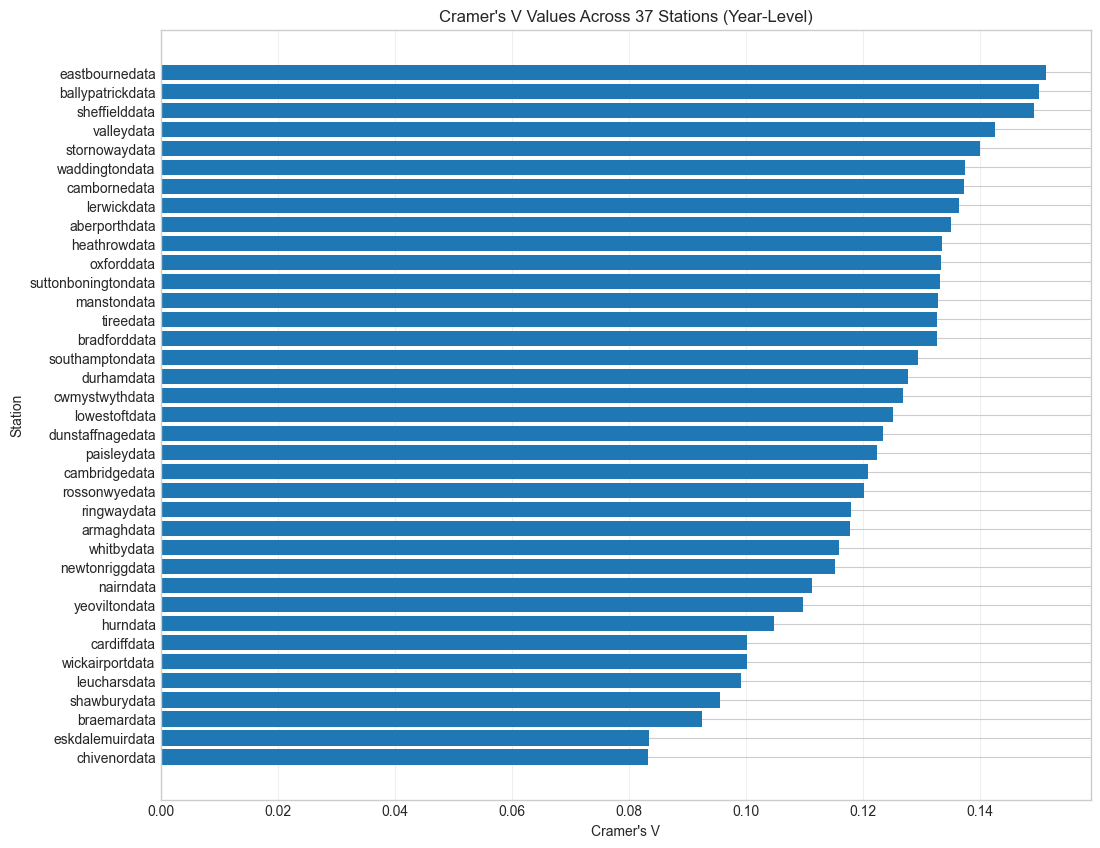

In [65]:
summary_year_sorted = summary_year.sort_values("CramerV", ascending=False)

plt.figure(figsize=(12,10))
plt.barh(summary_year_sorted["Station"], summary_year_sorted["CramerV"])
plt.title("Cramer's V Values Across 37 Stations (Year-Level)")
plt.xlabel("Cramer's V")
plt.ylabel("Station")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()

plt.show()


### Chi-square Test Results for Oxford (Year Table)

This code performs a chi-square test of independence on the annual (Year × FrostDays) frost table for the Oxford station. The calculated chi-square statistic, p-value, degrees of freedom, and Cramer's V measure how strongly the distribution of frost days differs across years, indicating whether year-to-year changes in frost frequency are statistically significant.


In [66]:
# Load Oxford station data
df_ox = pd.read_csv("oxforddata.csv")

# Run the chi-square test on Oxford’s Year × FrostDays table
chi2_y, p_y, dof_y, expected_y, obs_year_ox, cramer_y = chi_square_frost_year(df_ox)

# Display chi-square test results for Oxford (Year-level)
print("Oxford – Year × FrostDays chi-square results:")
print(f"Chi-square: {chi2_y:.3f}")
print(f"P-value: {p_y:.3e}")
print(f"Degrees of freedom: {dof_y}")
print(f"Cramer's V: {cramer_y:.3f}")


Oxford – Year × FrostDays chi-square results:
Chi-square: 1122.145
P-value: 4.143e-139
Degrees of freedom: 172
Cramer's V: 0.133


The chi-square test shows an extremely significant result (p < 0.001), indicating that the number of frost days in Oxford has changed across years. However, the effect size remains small (Cramer's V ≈ 0.13), meaning that while the change is statistically strong, the practical strength of the association is still weak-to-moderate.

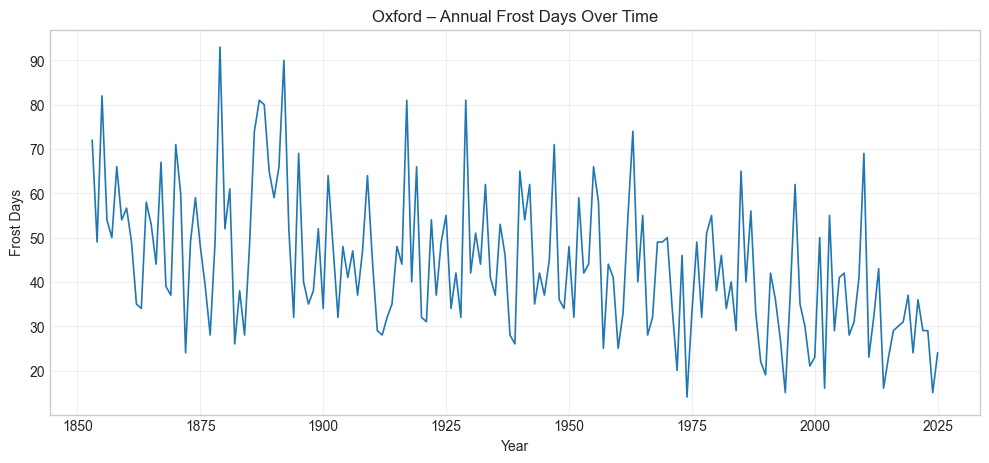

In [67]:
# Load Oxford station data
df_ox = pd.read_csv("oxforddata.csv")

# Construct the Year × FrostDays table using the preprocessing functions from Step 1
year_table_ox = prepare_frost_year_table(df_ox)

# Plot annual frost days to visualise long-term variation
plt.figure(figsize=(12,5))
plt.plot(year_table_ox.index, year_table_ox["Frost_days"], linewidth=1.2)

plt.title("Oxford – Annual Frost Days Over Time")
plt.xlabel("Year")
plt.ylabel("Frost Days")
plt.grid(alpha=0.3)

plt.show()


The plot visualises Oxford’s year-to-year frost-day variability across the full annual record.


## Step 3 – Overall Conclusion (Decade + Year Analysis)

This task examined whether the number of frost days has changed over time, using both decade-level (DJF winter months) and year-level (annual FrostDays) chi-square independence tests across 37 stations in the UK. The combined results provide strong statistical evidence of temporal change, although the strength of this change is generally modest.

---

### Decade Analysis (Winter DJF)

- Across most stations, p-values are extremely small (10⁻⁹ to 10⁻⁶¹).  
- This indicates statistically significant changes in frost days across decades.  
- Cramer's V values typically fall between **0.06 and 0.16**, suggesting a **weak to moderate** association.  
- A few stations (e.g., Chivenor) show p > 0.05, indicating no detectable decade-level change.

Conclusion:
The decade-level test confirms that long-term frost-day patterns have changed over time. However, the magnitude of this change is generally modest.

---

### Year Analysis (Whole Year × FrostDays)

- P-values are extremely small at nearly all stations (10⁻¹⁶ to 10⁻¹⁵⁹).  
- This shows that frost days also vary significantly from year to year.  
- Cramer's V values remain in the **0.09–0.15** range, consistent with a **weak to moderate** association.  
- Chi-square statistics are higher than in the decade analysis due to the greater temporal resolution of annual data.

Conclusion:
Year-level variation is more pronounced than decade-level variation, but the effect size remains limited. Frost days clearly change from year to year, though the magnitude of these changes is not large.

---

### Overall Interpretation (Combining Both Analyses)

- Both decade and year tests consistently show **strong statistical evidence** that frost days have changed over time.  
- However, Cramer’s V values indicate that the **practical effect size is limited**, despite the statistical significance.  
- While the degree of change varies across stations, most locations display a similar pattern:  
  **statistically detectable change, but with a weak-to-moderate strength of association.**

---

### Short Summary

Frost days have changed significantly over time across the UK, both at decade and year scales.  
However, the overall magnitude of this change is **modest**, as reflected by the low-to-moderate effect sizes.

---


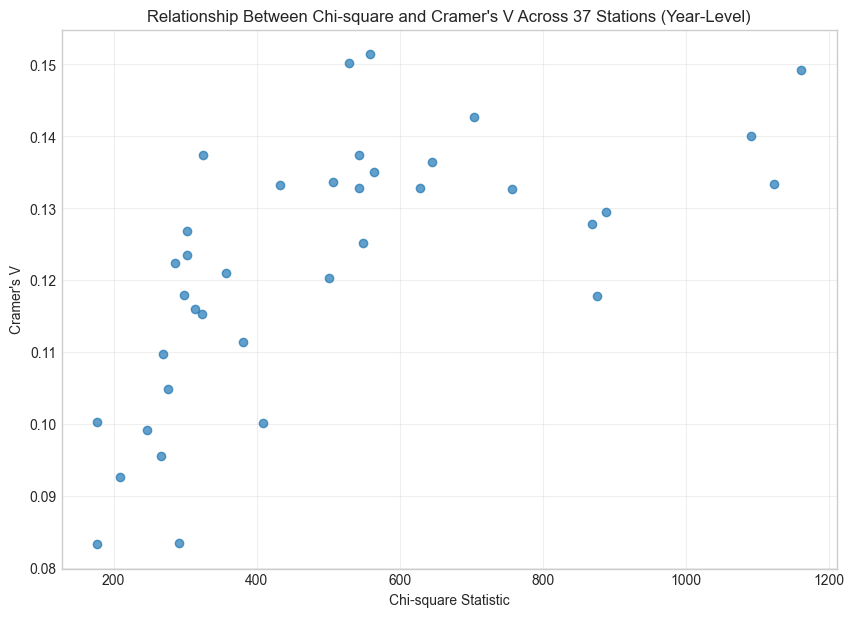

In [68]:
plt.figure(figsize=(10,7))

plt.scatter(summary_year["Chi2"], summary_year["CramerV"], alpha=0.7)

plt.title("Relationship Between Chi-square and Cramer's V Across 37 Stations (Year-Level)")
plt.xlabel("Chi-square Statistic")
plt.ylabel("Cramer's V")
plt.grid(alpha=0.3)

plt.show()


This plot illustrates how stations with stronger chi-square evidence for year-to-year changes tend to have slightly higher effect sizes, although overall associations remain weak to moderate.

## Part 4 — Summary and Conclusions

This analysis brought together descriptive analysis, trend estimation, and hypothesis testing to investigate evidence of climate change across 37 UK weather stations.